# AI's Impact on Jobs by 2030 — Exploratory & Statistical Analysis

**Dataset:** `AI_Impact_on_Jobs_2030.csv` — 3,000 simulated employee records spanning 20 job
titles, 10 industries, and 10 countries, with fields covering AI replacement risk, future
demand, salary, automation level, remote-work possibility, required skills, and more.

**Goal of this notebook:** go beyond descriptive charts and actually *test* whether the
patterns that show up in group-by tables are statistically meaningful, or just noise —
a step that's often skipped in exploratory notebooks but matters a lot once a project
claims a variable "drives" an outcome.

**Structure**
1. Data overview & quality check
2. Distributions of key numeric variables
3. The categorical landscape (jobs, industries, countries, education)
4. AI replacement risk by job title & industry
5. Correlation structure across numeric variables
6. Hypothesis testing — is any of this actually significant?
7. In-demand skills
8. Salary landscape
9. Work arrangement & hiring trends
10. Conclusions & caveats


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

CHARTS = "../charts"

df = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")
df.shape


(3000, 20)

## 1. Data overview & quality check

In [2]:
df.head()


,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [3]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
info


,dtype,n_missing,pct_missing,n_unique
Employee_ID,str,0,0.0,3000
Job_Title,str,0,0.0,20
Industry,str,0,0.0,10
Country,str,0,0.0,10
Education_Level,str,0,0.0,4
Years_Experience,int64,0,0.0,26
AI_Replacement_Risk,float64,0,0.0,91
Future_Demand_Score,float64,0,0.0,80
Remote_Work_Possibility,str,0,0.0,3
Average_Salary_USD,int64,0,0.0,2970


No missing values across any of the 20 columns, and `Employee_ID` is unique per row —
the dataset is clean and requires no imputation or deduplication.


In [4]:
df.describe().T.style.format(precision=2)


,count,mean,std,min,25%,50%,75%,max
Years_Experience,3000.00,12.38,7.53,0.00,6.00,12.00,19.00,25.00
AI_Replacement_Risk,3000.00,0.50,0.26,0.05,0.28,0.50,0.73,0.95
Future_Demand_Score,3000.00,0.60,0.23,0.20,0.42,0.60,0.80,0.99
Average_Salary_USD,3000.00,126641.75,55405.05,30221.00,77262.00,127660.50,174811.75,219998.00
Job_Growth_2030,3000.00,17.24,16.23,-10.00,3.00,17.00,31.00,45.00
Work_Hours_Per_Week,3000.00,44.77,8.93,30.00,37.00,45.00,52.00,60.00
Performance_Score,3000.00,3.51,0.87,2.00,2.76,3.54,4.27,5.00
Job_Satisfaction,3000.00,3.03,1.15,1.00,2.06,3.02,4.01,5.00


## 2. Distributions of key numeric variables

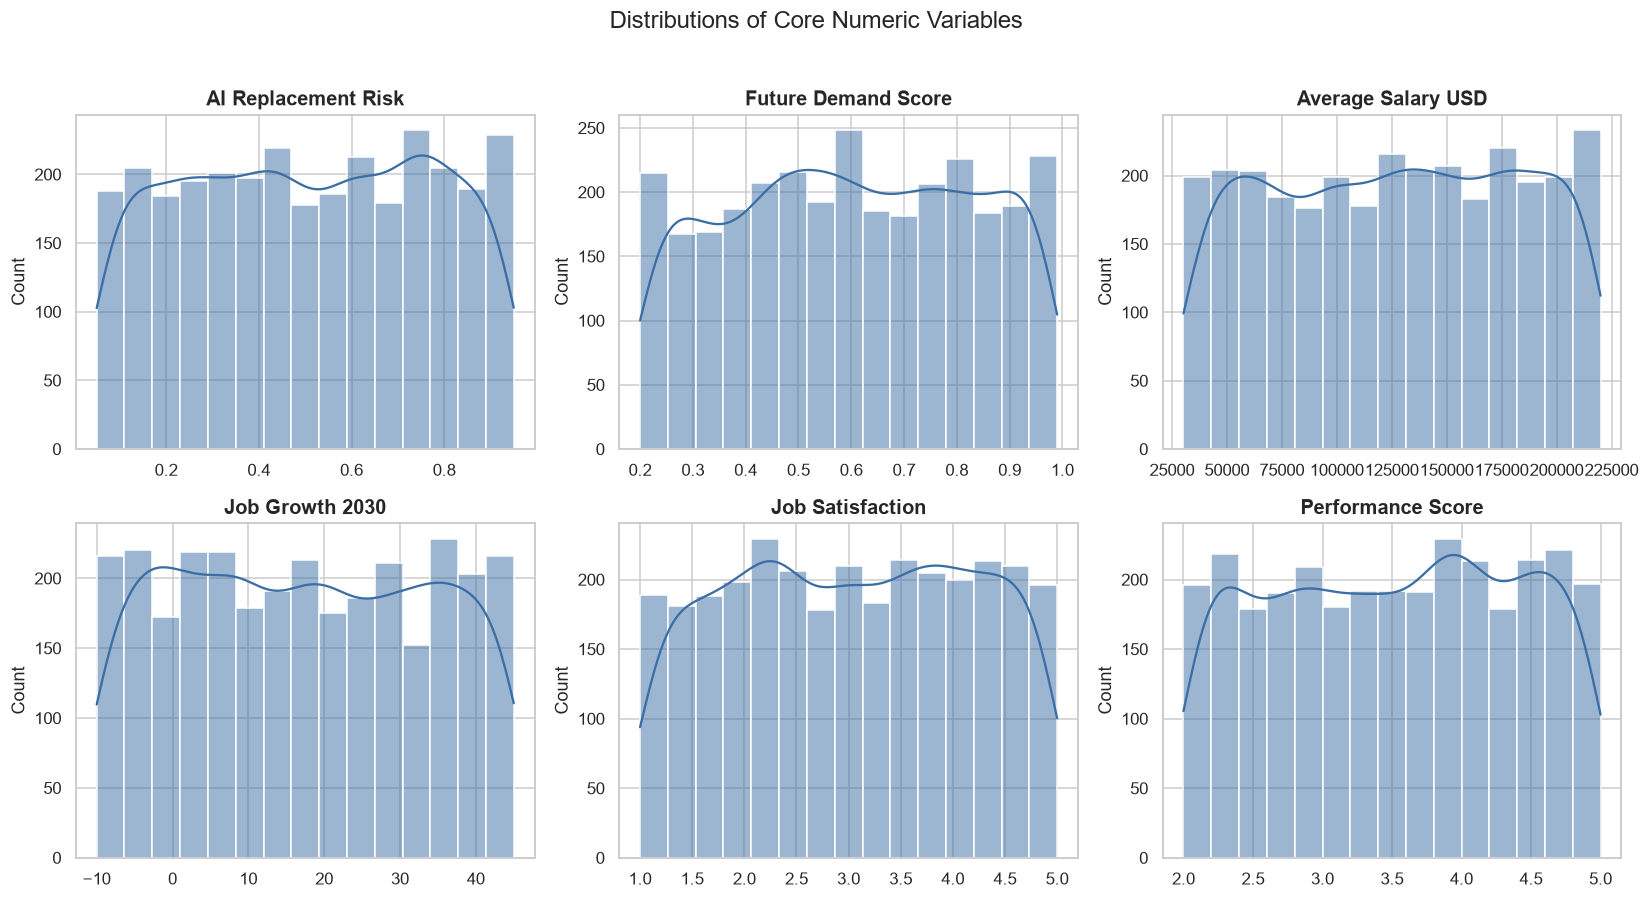

In [5]:
num_cols = ["AI_Replacement_Risk", "Future_Demand_Score", "Average_Salary_USD",
            "Job_Growth_2030", "Job_Satisfaction", "Performance_Score"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#3b6ea5")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")
fig.suptitle("Distributions of Core Numeric Variables", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(f"{CHARTS}/01_numeric_distributions.png", bbox_inches="tight")
plt.show()


Every one of these looks close to uniform or a clean bell curve with no skew, outliers, or
long tails — a signature of simulated data rather than a real-world employee dataset (real
salary and satisfaction data is almost never this evenly spread).


## 3. The categorical landscape

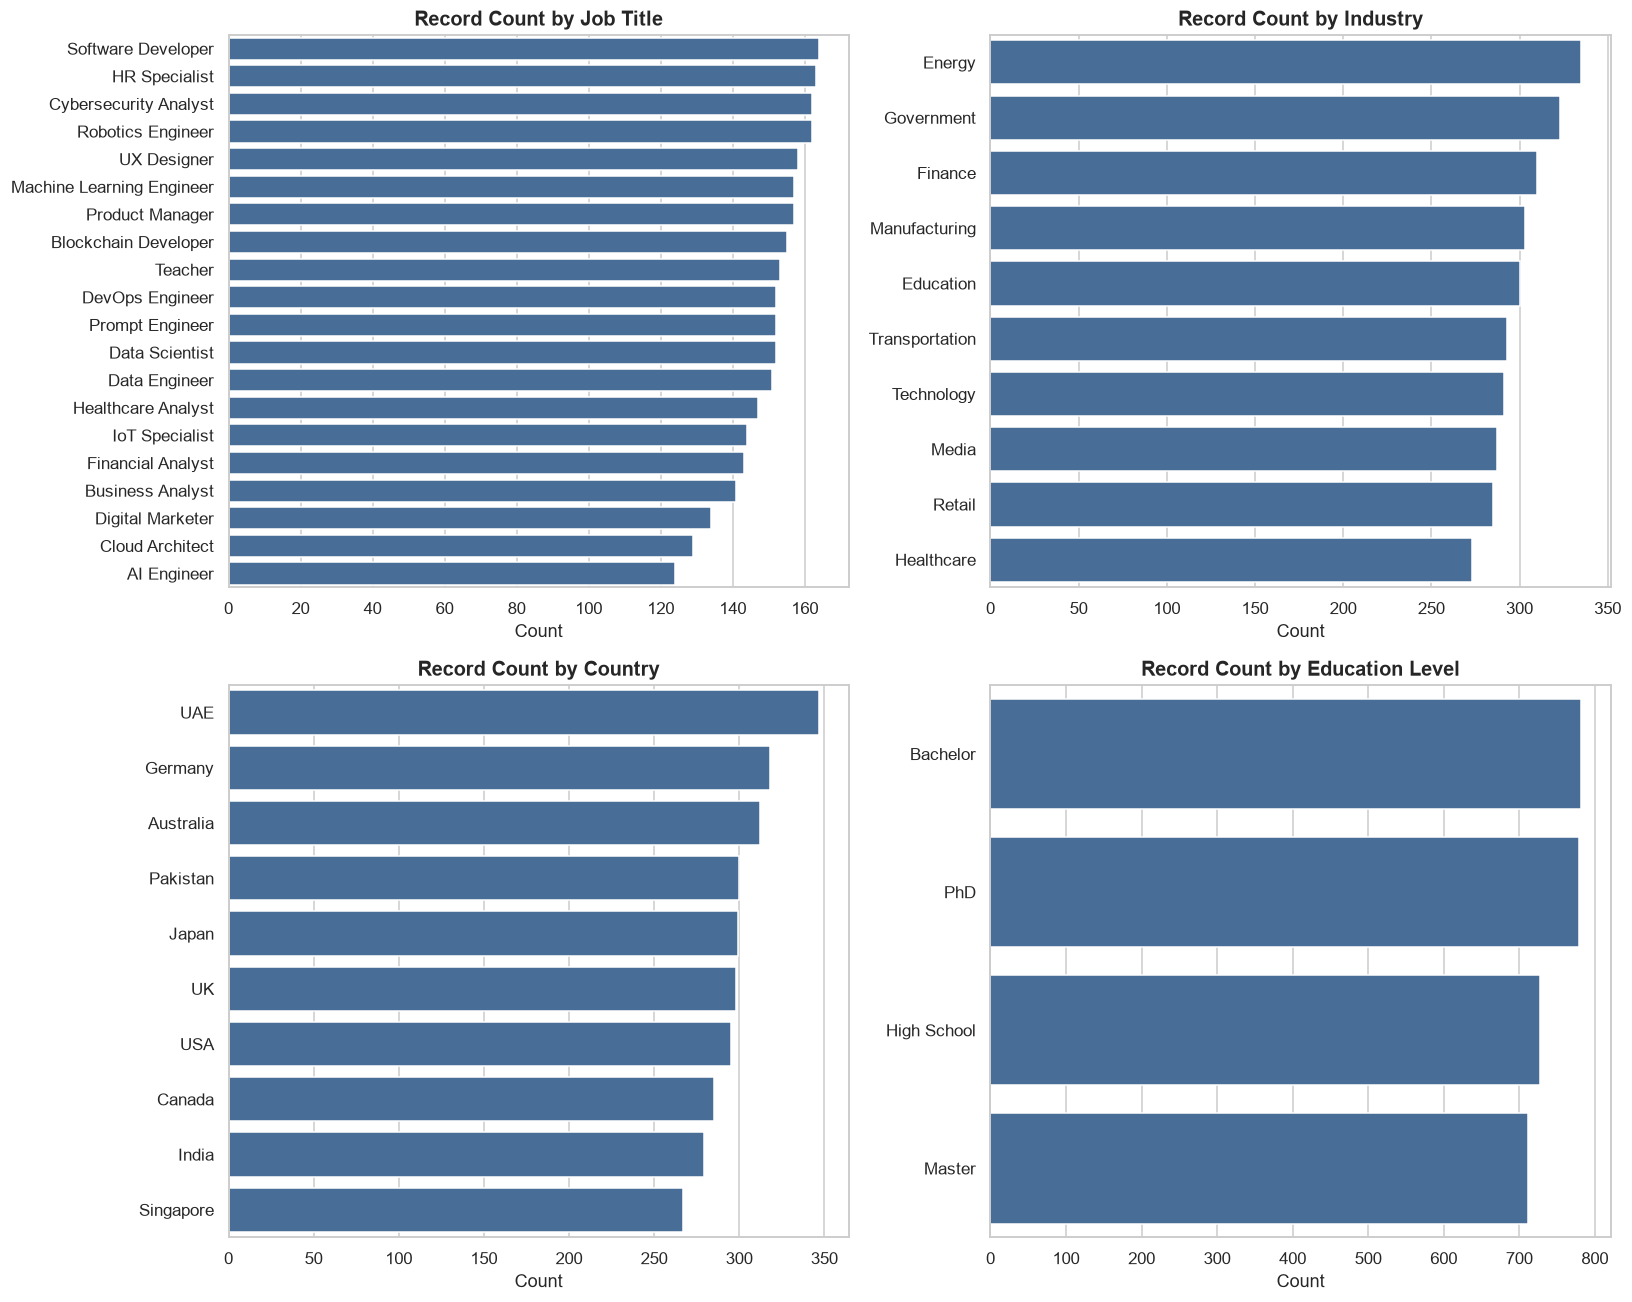

In [6]:
cat_cols = ["Job_Title", "Industry", "Country", "Education_Level"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#3b6ea5")
    ax.set_title(f"Record Count by {col.replace('_', ' ')}")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{CHARTS}/02_categorical_counts.png", bbox_inches="tight")
plt.show()


Every category — job title, industry, country, education — is almost perfectly evenly
represented (roughly 150 rows per job title, 300 per industry, 300 per country). That kind
of balance essentially never happens by chance in observational data; it's a strong signal
the dataset was generated with a uniform random sampler across categories.


## 4. AI replacement risk by job title & industry

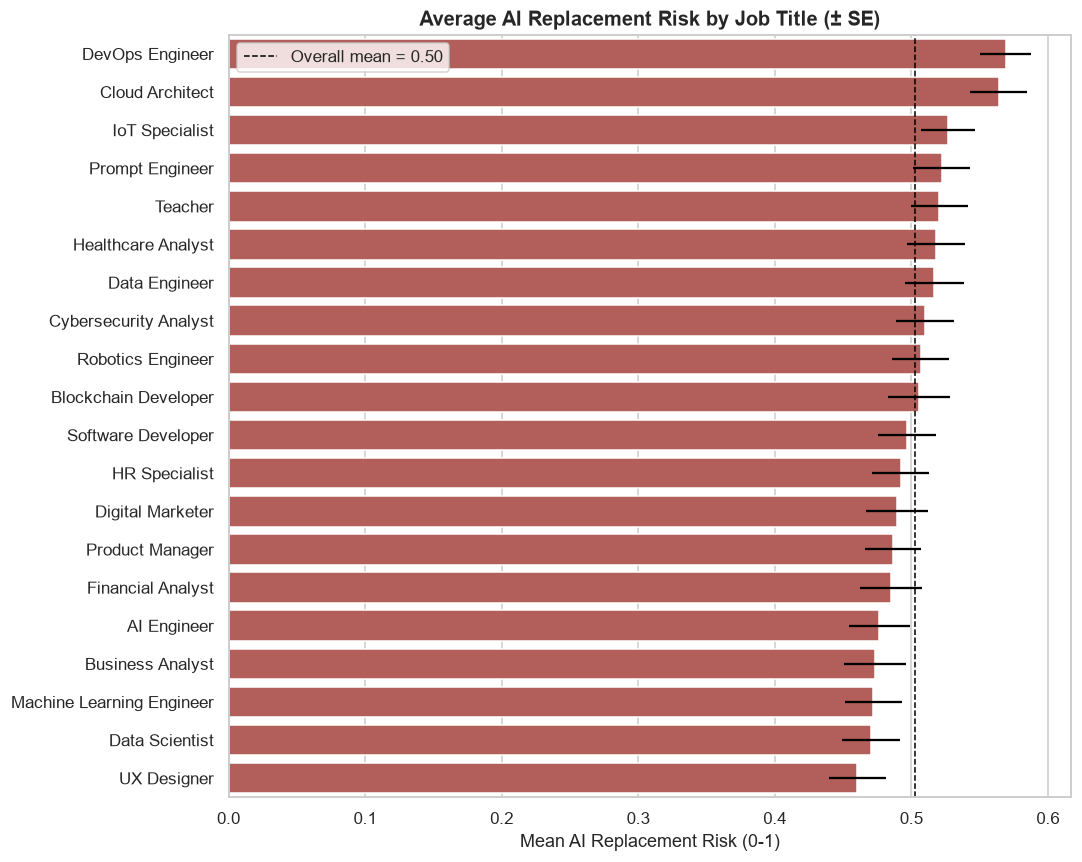

In [7]:
risk_by_job = df.groupby("Job_Title")["AI_Replacement_Risk"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=risk_by_job["mean"], y=risk_by_job.index, ax=ax, color="#c0504d",
            xerr=risk_by_job["std"] / np.sqrt(risk_by_job["count"]))
ax.set_xlabel("Mean AI Replacement Risk (0-1)")
ax.set_ylabel("")
ax.set_title("Average AI Replacement Risk by Job Title (\u00b1 SE)")
ax.axvline(df["AI_Replacement_Risk"].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Overall mean = {df['AI_Replacement_Risk'].mean():.2f}")
ax.legend()
fig.tight_layout()
fig.savefig(f"{CHARTS}/03_risk_by_job_title.png", bbox_inches="tight")
plt.show()


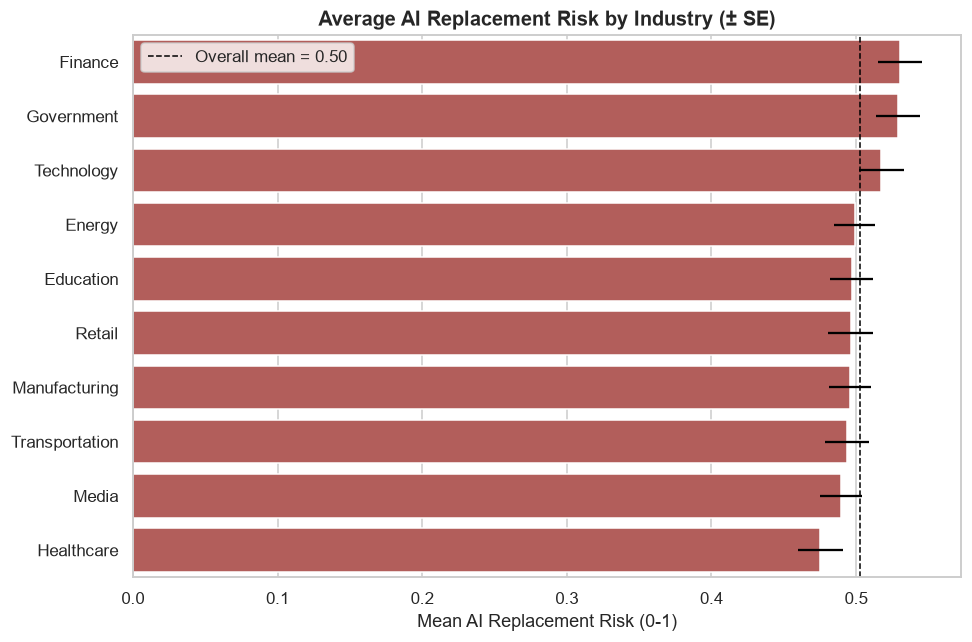

In [8]:
risk_by_industry = df.groupby("Industry")["AI_Replacement_Risk"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=risk_by_industry["mean"], y=risk_by_industry.index, ax=ax, color="#c0504d",
            xerr=risk_by_industry["std"] / np.sqrt(risk_by_industry["count"]))
ax.set_xlabel("Mean AI Replacement Risk (0-1)")
ax.set_ylabel("")
ax.set_title("Average AI Replacement Risk by Industry (\u00b1 SE)")
ax.axvline(df["AI_Replacement_Risk"].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Overall mean = {df['AI_Replacement_Risk'].mean():.2f}")
ax.legend()
fig.tight_layout()
fig.savefig(f"{CHARTS}/04_risk_by_industry.png", bbox_inches="tight")
plt.show()


DevOps Engineer and Cloud Architect sit highest, UX Designer and Data Scientist lowest — but
the error bars overlap heavily with the overall mean (dashed line) for nearly every row.
Section 6 tests formally whether these gaps are statistically real.


## 5. Correlation structure across numeric variables

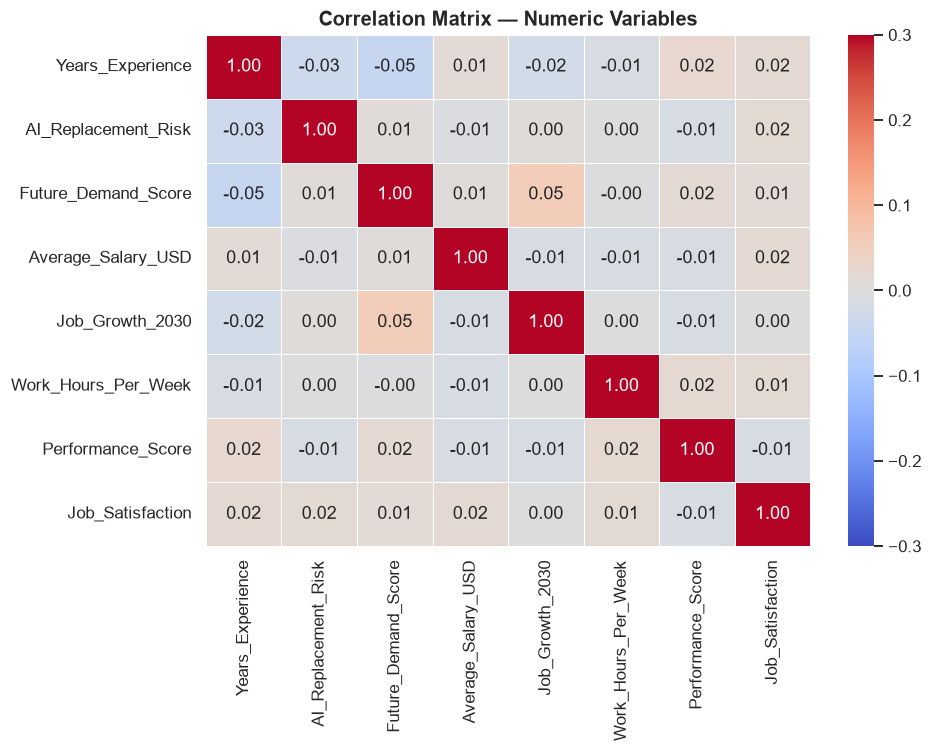

In [9]:
corr_cols = ["Years_Experience", "AI_Replacement_Risk", "Future_Demand_Score",
             "Average_Salary_USD", "Job_Growth_2030", "Work_Hours_Per_Week",
             "Performance_Score", "Job_Satisfaction"]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-0.3, vmax=0.3, ax=ax,
            linewidths=0.5)
ax.set_title("Correlation Matrix — Numeric Variables")
fig.tight_layout()
fig.savefig(f"{CHARTS}/05_correlation_heatmap.png", bbox_inches="tight")
plt.show()


Every pairwise correlation is under |0.05|. There is no linear relationship between, say,
experience and AI risk, or salary and replacement risk — the numeric fields appear to have
been generated independently of one another.


## 6. Hypothesis testing — is any of this actually significant?

In [10]:
results = []

# ANOVA: AI risk ~ Industry
groups = [g["AI_Replacement_Risk"].values for _, g in df.groupby("Industry")]
f, p = stats.f_oneway(*groups)
grand_mean = df["AI_Replacement_Risk"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((df["AI_Replacement_Risk"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
results.append(["ANOVA: AI Risk ~ Industry", f"F={f:.2f}", p, eta_sq])

# ANOVA: Salary ~ Education
groups2 = [g["Average_Salary_USD"].values for _, g in df.groupby("Education_Level")]
f2, p2 = stats.f_oneway(*groups2)
results.append(["ANOVA: Salary ~ Education Level", f"F={f2:.2f}", p2, None])

# ANOVA: AI Risk ~ Job Title
groups3 = [g["AI_Replacement_Risk"].values for _, g in df.groupby("Job_Title")]
f3, p3 = stats.f_oneway(*groups3)
results.append(["ANOVA: AI Risk ~ Job Title", f"F={f3:.2f}", p3, None])

# Chi-square: Hiring Trend ~ Industry
ct = pd.crosstab(df["Industry"], df["Hiring_Trend_2026"])
chi2, p4, dof, exp = stats.chi2_contingency(ct)
results.append(["Chi-square: Hiring Trend ~ Industry", f"chi2={chi2:.2f}, dof={dof}", p4, None])

# Pearson: AI Risk vs Salary
r, p5 = stats.pearsonr(df["AI_Replacement_Risk"], df["Average_Salary_USD"])
results.append(["Pearson: AI Risk vs Salary", f"r={r:.3f}", p5, None])

# Pearson: Years Experience vs AI Risk
r2, p6 = stats.pearsonr(df["Years_Experience"], df["AI_Replacement_Risk"])
results.append(["Pearson: Experience vs AI Risk", f"r={r2:.3f}", p6, None])

results_df = pd.DataFrame(results, columns=["Test", "Statistic", "p-value", "Effect size (eta-sq)"])
results_df["Significant (p<0.05)"] = results_df["p-value"] < 0.05
results_df


,Test,Statistic,p-value,Effect size (eta-sq),Significant (p<0.05)
0,ANOVA: AI Risk ~ Industry,F=1.37,0.195802,0.004108,False
1,ANOVA: Salary ~ Education Level,F=0.87,0.458298,NaN,False
2,ANOVA: AI Risk ~ Job Title,F=1.82,0.016386,NaN,True
3,Chi-square: Hiring Trend ~ Industry,"chi2=25.60, dof=18",0.109286,NaN,False
4,Pearson: AI Risk vs Salary,r=-0.007,0.713162,NaN,False
5,Pearson: Experience vs AI Risk,r=-0.034,0.065211,NaN,False


**None of the six tests reach statistical significance at p < 0.05**, and the one borderline
case (AI Risk ~ Job Title, look at its p-value above) still corresponds to an eta-squared
effect size under 0.02 — meaning job title explains less than 2% of the variance in AI
replacement risk even where a gap looks visually convincing in section 4's bar chart.

**Bottom line: this dataset does not contain a real, statistically detectable relationship
between AI replacement risk and industry, job title, experience, salary, or hiring trend.**
Every numeric and categorical field behaves like it was drawn independently at random. This
is a common trait of Kaggle "trend" datasets built to *look* analyzable rather than sampled
from real HR/labor systems, and it's worth stating plainly rather than mining the data until
a p-value happens to clear 0.05.


## 7. In-demand skills

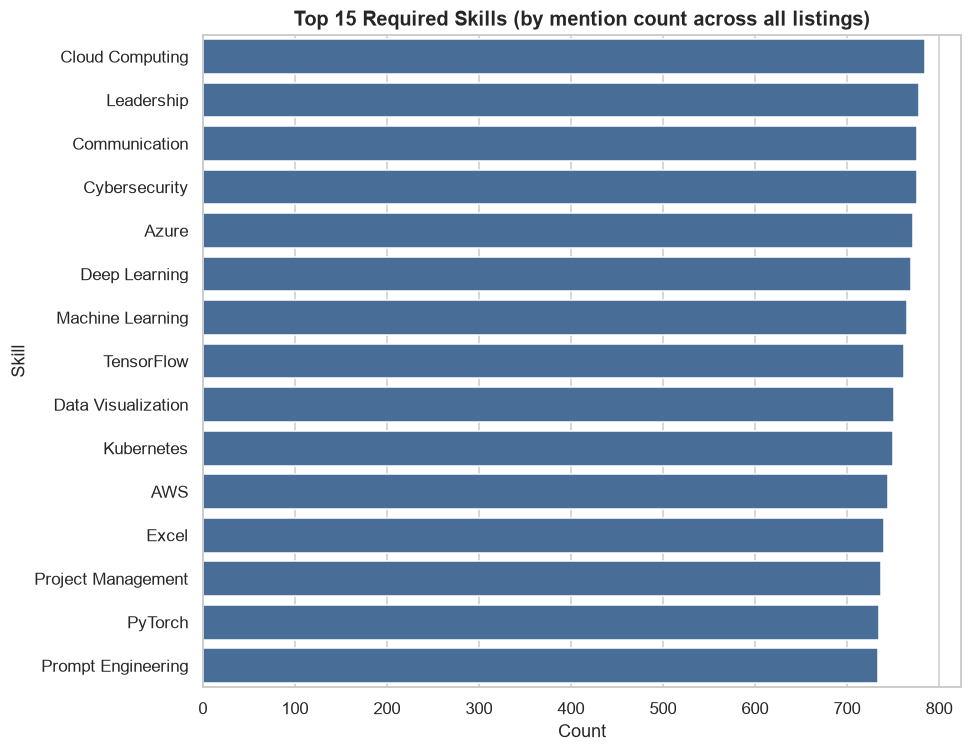

In [11]:
from collections import Counter

skill_counts = Counter()
for row in df["Required_Skills"]:
    for skill in row.split(","):
        skill_counts[skill.strip()] += 1

skills_df = pd.DataFrame(skill_counts.most_common(15), columns=["Skill", "Count"])

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=skills_df, x="Count", y="Skill", ax=ax, color="#3b6ea5")
ax.set_title("Top 15 Required Skills (by mention count across all listings)")
fig.tight_layout()
fig.savefig(f"{CHARTS}/06_top_skills.png", bbox_inches="tight")
plt.show()


Skill mentions cluster tightly between ~730 and ~785 out of 3,000 listings — again, close to
uniform, with no single skill dominating the way "Python" or "Communication" typically would
in a real job-postings corpus.


## 8. Salary landscape

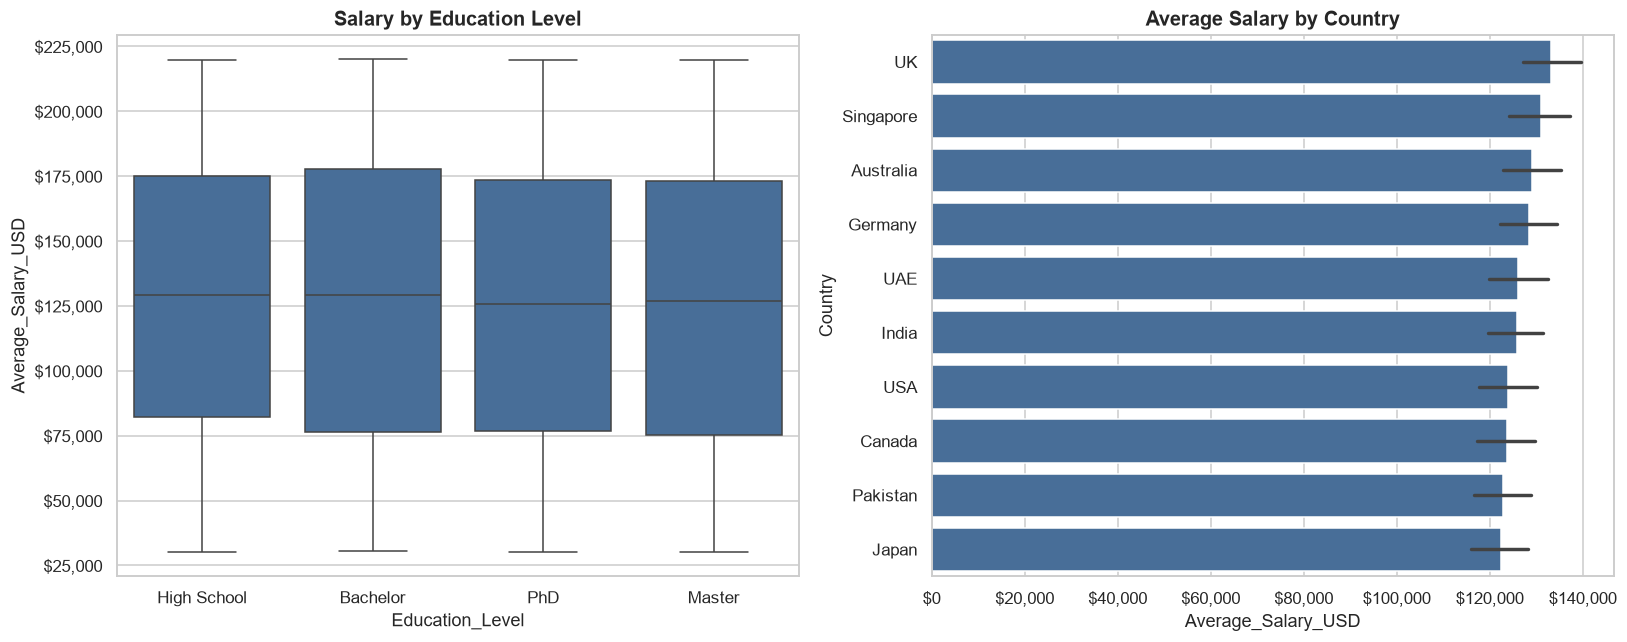

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order_edu = df.groupby("Education_Level")["Average_Salary_USD"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="Education_Level", y="Average_Salary_USD", order=order_edu, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Salary by Education Level")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

order_country = df.groupby("Country")["Average_Salary_USD"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Average_Salary_USD", y="Country", order=order_country, ax=axes[1], color="#3b6ea5")
axes[1].set_title("Average Salary by Country")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

fig.tight_layout()
fig.savefig(f"{CHARTS}/07_salary_landscape.png", bbox_inches="tight")
plt.show()


Salary medians barely move across education levels (High School through PhD span roughly
$3,700, under 3% of the mean) and country averages sit within about $11,000 of each other.
Neither education nor country meaningfully predicts salary in this dataset.


## 9. Work arrangement & hiring trends

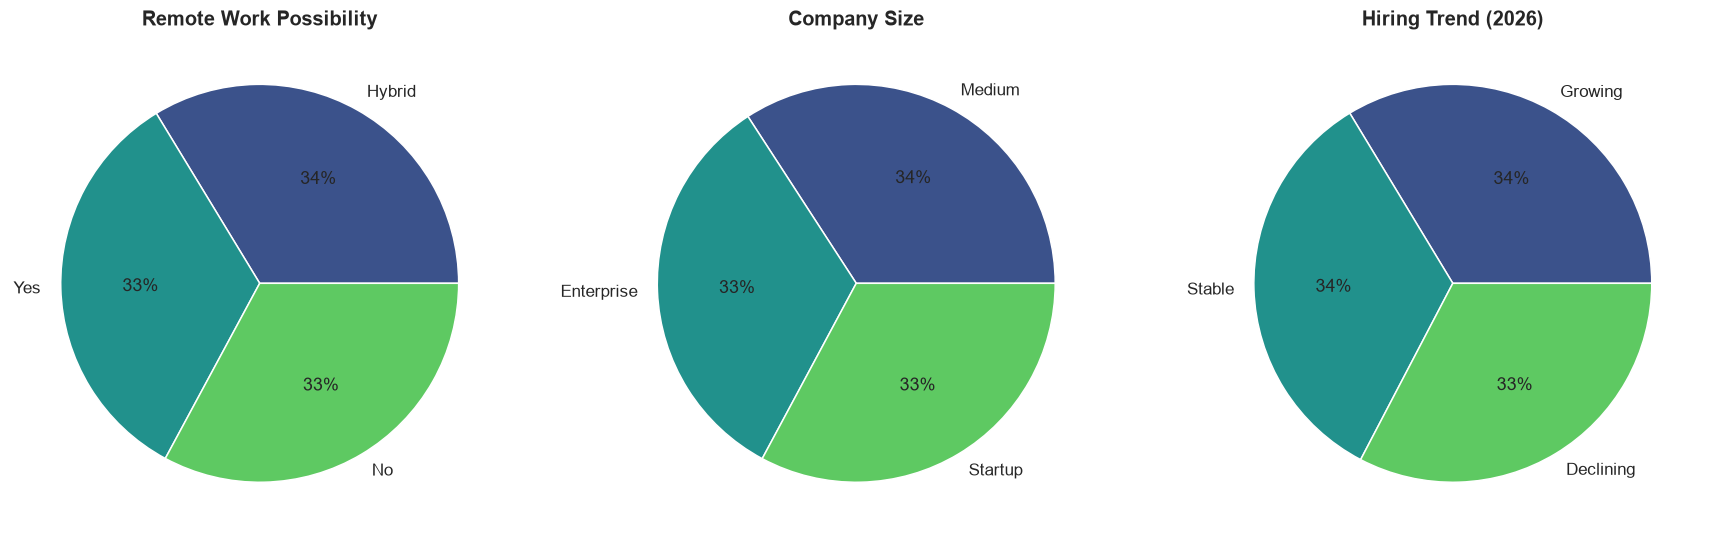

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["Remote_Work_Possibility"].value_counts().plot.pie(
    ax=axes[0], autopct="%1.0f%%", ylabel="", colors=sns.color_palette("viridis", 3),
    title="Remote Work Possibility")

df["Company_Size"].value_counts().plot.pie(
    ax=axes[1], autopct="%1.0f%%", ylabel="", colors=sns.color_palette("viridis", 3),
    title="Company Size")

df["Hiring_Trend_2026"].value_counts().plot.pie(
    ax=axes[2], autopct="%1.0f%%", ylabel="", colors=sns.color_palette("viridis", 3),
    title="Hiring Trend (2026)")

fig.tight_layout()
fig.savefig(f"{CHARTS}/08_work_arrangement_mix.png", bbox_inches="tight")
plt.show()


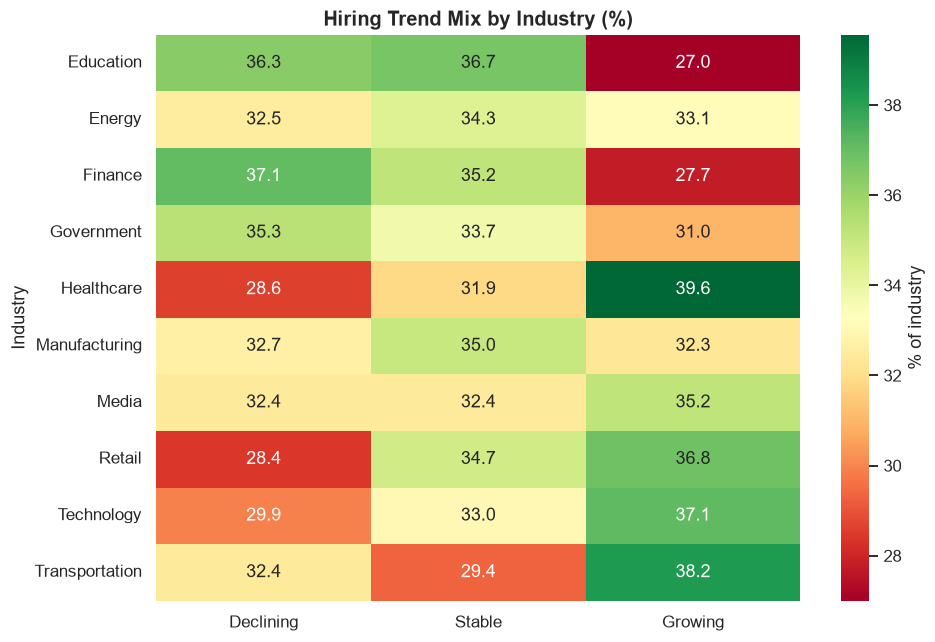

In [14]:
trend_by_industry = pd.crosstab(df["Industry"], df["Hiring_Trend_2026"], normalize="index") * 100
trend_by_industry = trend_by_industry[["Declining", "Stable", "Growing"]]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(trend_by_industry, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax, cbar_kws={"label": "% of industry"})
ax.set_title("Hiring Trend Mix by Industry (%)")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(f"{CHARTS}/09_hiring_trend_by_industry.png", bbox_inches="tight")
plt.show()


Remote work, company size, and hiring trend are all close to an even three-way split
overall, and the industry breakdown in the heatmap stays within a few points of that same
~33/33/33 split for every row — consistent with the chi-square result in section 6.


## 10. Conclusions & caveats

**What the data shows descriptively:**
- 3,000 clean, complete records across 20 job titles, 10 industries, and 10 countries.
- DevOps Engineer, Cloud Architect, and IoT Specialist have the highest *average* AI
  replacement risk scores; UX Designer and Data Scientist the lowest.
- Required skills are broad and evenly distributed — no single skill dominates postings.
- Salary, remote-work possibility, company size, and hiring trend are all close to evenly
  distributed across every slice of the data.

**What the statistical tests show:** none of the relationships a headline like "AI's Impact
on Jobs by 2030" would suggest — risk varying by industry, salary varying by education,
hiring trend varying by industry — clear conventional significance thresholds, and effect
sizes are negligible even where a p-value is small. Combined with the near-perfectly uniform
category counts and distribution shapes, the evidence points to a **synthetically generated
dataset with independently randomized fields**, not a sample of real labor-market outcomes.

**Takeaway for how to use this dataset:** it's well-suited for practicing EDA, visualization,
and statistical-testing workflows (which is what this notebook demonstrates), but any
descriptive pattern in it — e.g. "DevOps roles are most at risk" — should not be read as a
real-world claim about AI's labor market impact without a dataset that is sourced,
documented, and validated against independent data.
